# Objetivo A — Métricas Custom para Reducción de Falsos Positivos
## Proyecto PLUS TI – Universidad del Valle 2025  ·  v3

**Cambios respecto a v2:**
- Carga desde dataset original (`Copia de 01_bo_vip_seed22_n100000.csv`) para recuperar
  columnas eliminadas por razones del modelo federado: `DE9_conversion_rate_billing`,
  `DE43_card_acceptor_name_location`, `client_id` (temporal, solo para features)
- Feature engineering ampliado: 8 features nuevos derivados de hallazgos del EDA
- `sample_weight` proporcional a monto como P6-M6 adicional

**Estructura:**
1. Setup y carga (dataset original + limpieza integrada)
2. Feature engineering completo (features v2 + 8 nuevos)
3. Split temporal + undersampling
4. Parámetros base y datasets LightGBM
5. Funciones auxiliares de evaluación
6. Paso 4 — punto común: reducir FP ratio con recall ≥ 90%
7. Paso 6 — objetivo del grupo: maximizar monto salvado en USD
8. Comparativas separadas + feature importance
9. Conclusión y selección

## 0. Setup e imports

In [1]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, precision_recall_curve
)
from sklearn.utils import resample

SEED = 22
np.random.seed(SEED)
print('LightGBM version:', lgb.__version__)

LightGBM version: 4.6.0


## 0.1 Configuración GPU

In [2]:
import subprocess

def check_gpu():
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            print('✓ GPU detectada')
            for line in result.stdout.split('\n'):
                if any(x in line for x in ['Tesla','T4','A100','V100','RTX','GTX']):
                    print(' ', line.strip())
            return True
        print('✗ No se detectó GPU'); return False
    except FileNotFoundError:
        print('✗ nvidia-smi no encontrado'); return False

GPU_AVAILABLE = check_gpu()
GPU_PARAMS = {'device':'gpu','gpu_platform_id':0,'gpu_device_id':0} if GPU_AVAILABLE else {}
print('\nGPU_PARAMS:', GPU_PARAMS if GPU_PARAMS else 'CPU mode')

✓ GPU detectada
  |   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

GPU_PARAMS: {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}


## 1. Carga del dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
PATH_OUTPUTS  = PATH_PROJECT + 'models/modelo_a'
os.makedirs(PATH_OUTPUTS, exist_ok=True)

# ── Cargar dataset ORIGINAL (no el limpio) ────────────────────────────────────
# Necesitamos client_id para features de comportamiento histórico,
# y columnas que el EDA eliminó por razones del modelo federado.
FILE_RAW = 'Copia de 01_bo_vip_seed22_n100000.csv'
df_raw = pd.read_csv(PATH_DATASETS + FILE_RAW, sep=';', low_memory=False)
print(f'Dataset original: {df_raw.shape[0]:,} filas | {df_raw.shape[1]} columnas')

# Conversión is_fraud
df_raw['is_fraud'] = (
    df_raw['is_fraud']
    .map({'True':1,'False':0,True:1,False:0,1:1,0:0})
    .fillna(0).astype(int)
)
print(f'Tasa de fraude  : {df_raw["is_fraud"].mean():.2%}')

Mounted at /content/drive
Dataset original: 100,003 filas | 66 columnas
Tasa de fraude  : 4.92%


## 2. Limpieza + Feature Engineering

La limpieza se hace en dos etapas:
1. **Parseo de fechas y extracción de `month`** — antes de cualquier drop
2. **Feature engineering** — usando `client_id` y columnas recuperadas, antes de eliminarlos
3. **Drop y encodings** — igual que el EDA original

### Columnas recuperadas respecto al EDA original (modelo federado)

| Columna | Por qué el EDA la eliminó | Por qué la recuperamos |
|---|---|---|
| `DE9_conversion_rate_billing` | Multicolineal con `is_international` (r=0.82) | Informa la *magnitud* de la internacionalidad, no solo si/no |
| `DE43_card_acceptor_name_location` | Identificador no federable entre bancos | Para modelo centralizado: comercios con alta tasa de fraude |
| `client_id` | Identificador de privacidad | Solo para calcular features históricos por cliente; se elimina después |

In [4]:
# Columnas a eliminar (misma lógica que EDA + federado)
COLS_ID = [
    'transaction_id','client_id','pan_masked','pan_hash',
    'DE2_PAN','DE35_track2_data_masked','DE11_STAN',
    'DE37_retrieval_reference_number','DE38_authorization_code',
    'DE41_terminal_id','DE42_card_acceptor_id',
    'DE56_original_data','DE102_account_id_1','DE103_account_id_2',
]
COLS_FECHA = [
    'DE7_transmission_datetime','DE12_local_time','DE13_local_date',
    'DE14_expiration_date','DE15_settlement_date',
]

# Columnas con >80% nulos en el dataset original (verificado en EDA)
COLS_HIGH_NULL = [
    'DE56_original_data','DE54_additional_amounts',
    'DE48_additional_data','DE103_account_id_2','DE44_additional_response_data',
]

# Columnas de leakage — conocidas solo post-autorización
COLS_LEAKAGE = ['approved', 'response_description']

# Excluir del feature set (target + auxiliares de tiempo)
EXCLUDE_FROM_FEATURES = ['is_fraud', 'datetime_tx', 'month']

CAT_COLS = [
    'bank_code','bank_name','bank_country','bank_tier',
    'client_segment','channel','card_brand',
    'day_of_week','currency_tx_alpha',
    'DE52_pin_data_present','DE55_emv_data_present',
    'DE60_pos_terminal_type','DE63_network_specific',
    'DE123_pos_data_code',
    'DE43_card_acceptor_name_location',  # recuperada: comercio como categórica
]

TARGET = 'is_fraud'
print('Configuración de columnas lista.')
print(f'  Leakage excluido  : {COLS_LEAKAGE}')
print(f'  Categóricas       : {len(CAT_COLS)} columnas (incl. card_acceptor_name)')

Configuración de columnas lista.
  Leakage excluido  : ['approved', 'response_description']
  Categóricas       : 15 columnas (incl. card_acceptor_name)


In [5]:
def preparar_dataset(df_input):
    """
    Limpieza + feature engineering completo sobre el dataset original.
    Mantiene client_id solo durante el cálculo de features históricos.
    Retorna df listo para modelar (sin client_id, sin leakage, sin fechas raw).
    """
    df = df_input.copy()
    print(f'Inicio: {df.shape}')

    # ── 1. Parseo de fechas ────────────────────────────────────────────────────
    if 'DE13_local_date' in df.columns and 'DE12_local_time' in df.columns:
        de13 = df['DE13_local_date'].astype(str).str.zfill(4)
        de12 = df['DE12_local_time'].astype(str).str.zfill(6)
        df['datetime_tx'] = pd.to_datetime(
            '2025' + de13 + de12, format='%Y%m%d%H%M%S', errors='coerce'
        )
        df['month'] = pd.to_numeric(de13.str[:2], errors='coerce')
    print(f'  Fechas OK: {df["month"].between(1,12).sum():,}')

    # Ordenar por cliente y tiempo — necesario para todos los features históricos
    df = df.sort_values(['client_id','datetime_tx']).reset_index(drop=True)

    # ── 2. Features del EDA original ──────────────────────────────────────────
    # time_since_last_txn_min
    df['prev_dt'] = df.groupby('client_id')['datetime_tx'].shift(1)
    df['time_since_last_txn_min'] = (
        (df['datetime_tx'] - df['prev_dt']).dt.total_seconds() / 60
    ).fillna(-1)
    df.drop(columns=['prev_dt'], inplace=True)

    # txn_count_last_1h / 24h (rolling temporal)
    df = df.set_index('datetime_tx')
    for w, col in [('1h','txn_count_last_1h'), ('24h','txn_count_last_24h')]:
        df[col] = (
            df.groupby('client_id')['amount_usd']
              .transform(lambda x: x.rolling(w, closed='left').count())
              .fillna(0).astype(int)
        )
    df = df.reset_index()

    # amount_zscore_customer
    stats = df.groupby('client_id')['amount_usd'].agg(
        c_mean='mean', c_std='std'
    ).reset_index()
    df = df.merge(stats, on='client_id', how='left')
    df['amount_zscore_customer'] = (
        (df['amount_usd'] - df['c_mean']) / (df['c_std'].fillna(1) + 1e-6)
    ).fillna(0)
    df.drop(columns=['c_mean','c_std'], inplace=True)

    # ── 3. Features nuevos — comportamiento histórico por cliente ──────────────
    # ¿El cliente alguna vez hizo transacciones internacionales antes?
    # Si is_international=1 y first_intl_txn_pct=0 → primera vez = más sospechoso
    df['first_intl_txn_pct'] = (
        df.groupby('client_id')['is_international']
          .transform(lambda x: x.expanding().mean().shift(1))
          .fillna(0)
    )

    # Ratio monto vs máximo histórico del cliente
    # ratio > 1 = monto nunca visto antes para ese cliente
    df['amount_vs_max_historical'] = (
        df['amount_usd'] /
        df.groupby('client_id')['amount_usd']
          .transform(lambda x: x.expanding().max().shift(1).fillna(x) + 1e-9)
    )

    # ── 4. Features nuevos — monto relativo ────────────────────────────────────
    # Ratio vs baseline histórico del cliente
    df['amount_ratio_vs_baseline'] = (
        df['amount_usd'] / (df['client_baseline_amount'] + 1e-9)
    )

    # Percentil del monto en la distribución global
    df['amount_percentile'] = df['amount_usd'].rank(pct=True)

    # Flag: top 10% de montos (donde el EDA muestra concentración de fraudes)
    p90_global = df['amount_usd'].quantile(0.90)
    df['is_high_amount'] = (df['amount_usd'] >= p90_global).astype(int)

    # ── 5. Features nuevos — interacciones del EDA ────────────────────────────
    # Horario nocturno (11pm–5am): tasa de fraude ~8% vs ~4.5% diurno (EDA)
    df['is_night'] = (
        (df['hour_local'] >= 23) | (df['hour_local'] <= 5)
    ).astype(int)

    # ECOM + alto monto: los dos hallazgos principales del EDA combinados
    # ECOM tiene 8% tasa fraude; fraudes se concentran en montos altos
    df['ecom_high_amount'] = (
        (df['channel'] == 'ECOM') & (df['amount_usd'] >= p90_global)
    ).astype(int)

    # Internacional + alto monto
    df['international_high_amount'] = (
        (df['is_international'] == True) & (df['amount_usd'] >= p90_global)
    ).astype(int)

    # ── 6. Features nuevos — zscore por canal ─────────────────────────────────
    # Un monto de USD 1000 es normal en ECOM pero anómalo en POS
    ch_mean = df.groupby('channel')['amount_usd'].transform('mean')
    ch_std  = df.groupby('channel')['amount_usd'].transform('std').fillna(1)
    df['amount_zscore_channel'] = (
        (df['amount_usd'] - ch_mean) / (ch_std + 1e-6)
    ).fillna(0)

    # ── 7. Interacciones intensidad ───────────────────────────────────────────
    df['amount_x_zscore']   = df['amount_zscore_customer'].abs() * df['amount_usd']
    df['velocity_x_amount'] = df['txn_count_last_1h'] * df['amount_usd']

    print(f'  Features construidos: {[c for c in df.columns if c not in df_input.columns]}')

    # ── 8. Drop columnas no necesarias ────────────────────────────────────────
    high_null = list(df.columns[df.isnull().mean() > 0.80])
    to_drop = list(set(
        COLS_ID + COLS_FECHA + COLS_HIGH_NULL + COLS_LEAKAGE + high_null
    ))
    to_drop = [c for c in to_drop if c in df.columns]
    df.drop(columns=to_drop, inplace=True)
    print(f'  Eliminadas {len(to_drop)} columnas')

    # ── 9. Imputar nulos residuales ────────────────────────────────────────────
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any():
            df[col].fillna('UNKNOWN', inplace=True)

    print(f'Resultado: {df.shape} | Nulos residuales: {df.isnull().sum().sum()}')
    return df


df = preparar_dataset(df_raw)
print(f'\nDataset listo: {df.shape}')
print(f'Fraude: {df["is_fraud"].mean():.2%}')

Inicio: (100003, 66)
  Fechas OK: 100,003
  Features construidos: ['datetime_tx', 'month', 'time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h', 'amount_zscore_customer', 'first_intl_txn_pct', 'amount_vs_max_historical', 'amount_ratio_vs_baseline', 'amount_percentile', 'is_high_amount', 'is_night', 'ecom_high_amount', 'international_high_amount', 'amount_zscore_channel', 'amount_x_zscore', 'velocity_x_amount']
  Eliminadas 24 columnas
Resultado: (100003, 59) | Nulos residuales: 0

Dataset listo: (100003, 59)
Fraude: 4.92%


## 3. Encodings y selección de features

`DE43_card_acceptor_name_location` se trata como categórica de alta cardinalidad.
LightGBM maneja esto bien con `min_child_samples` adecuado; el Label Encoder
la convierte a entero y el modelo aprende los bins que predicen fraude.

In [6]:
label_encoders = {}
for col in CAT_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# ── Seguridad: encodear cualquier object residual que no esté en CAT_COLS ──────
# Columnas como client_home_city pueden sobrevivir el drop si no están listadas.
residual_obj = [
    c for c in df.columns
    if df[c].dtype == object and c not in (CAT_COLS + [TARGET])
]
if residual_obj:
    print(f'⚠ Columnas object residuales encontradas, aplicando LabelEncoder: {residual_obj}')
    for col in residual_obj:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# ── Verificación final de dtypes ───────────────────────────────────────────────
bad_dtypes = [c for c in df.columns if df[c].dtype == object and c != TARGET]
if bad_dtypes:
    print(f'✗ Todavía hay columnas object: {bad_dtypes} — eliminando del feature set')
    df.drop(columns=bad_dtypes, inplace=True)

EXCLUDE_ALL = EXCLUDE_FROM_FEATURES + COLS_LEAKAGE
FEATURES = [c for c in df.columns if c not in EXCLUDE_ALL]

# Verificar que todos los features son numéricos antes de llegar a lgb.Dataset
non_numeric = [c for c in FEATURES if df[c].dtype == object]
if non_numeric:
    raise ValueError(f'Features no numéricos: {non_numeric}')

print(f'Features totales: {len(FEATURES)}')
print('\nDetalle:')
for f in sorted(FEATURES):
    print(f'  {f}  [{df[f].dtype}]')

⚠ Columnas object residuales encontradas, aplicando LabelEncoder: ['client_home_city']
Features totales: 56

Detalle:
  DE100_receiving_institution_id  [float64]
  DE123_pos_data_code  [int64]
  DE18_merchant_category_code  [int64]
  DE19_acquirer_country_code  [int64]
  DE22_pos_entry_mode  [int64]
  DE23_card_seq_number  [float64]
  DE25_pos_condition_code  [int64]
  DE32_acquiring_institution_id  [int64]
  DE39_response_code  [int64]
  DE3_processing_code  [int64]
  DE43_card_acceptor_name_location  [int64]
  DE49_currency_code_transaction  [int64]
  DE4_amount_transaction  [int64]
  DE50_currency_code_settlement  [int64]
  DE51_currency_code_billing  [int64]
  DE52_pin_data_present  [int64]
  DE55_emv_data_present  [int64]
  DE58_authorizing_agent_id  [float64]
  DE60_pos_terminal_type  [int64]
  DE61_pos_extended_data  [float64]
  DE63_network_specific  [int64]
  DE6_amount_cardholder_billing  [int64]
  DE9_conversion_rate_billing  [float64]
  MTI  [int64]
  amount_local  [float64

In [7]:
train_mask = df['month'].isin([1, 2, 3])
test_mask  = df['month'].isin([4, 5, 6])

X_test        = df.loc[test_mask, FEATURES]
y_test        = df.loc[test_mask, TARGET]
amounts_test  = df.loc[test_mask, 'amount_usd'].values

# Undersampling 10:1 solo en train
from sklearn.utils import resample

fraud_train = df.loc[train_mask & (df[TARGET] == 1)]
legit_train = df.loc[train_mask & (df[TARGET] == 0)]
legit_down  = resample(
    legit_train, n_samples=len(fraud_train)*10,
    random_state=SEED, replace=False,
)
df_train_bal = pd.concat([legit_down, fraud_train]).sample(frac=1, random_state=SEED)

X_train       = df_train_bal[FEATURES]
y_train       = df_train_bal[TARGET]
amounts_train = df_train_bal['amount_usd'].values  # para sample_weight P6-M6

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
SPW   = n_neg / n_pos

# Percentil 75 de monto en fraudes test — umbral para P6-M3
HIGH_VALUE_THRESHOLD = np.percentile(amounts_test[y_test.values == 1], 75)
# Percentil 90 global — para is_high_amount
P90_GLOBAL = np.percentile(amounts_test, 90)

print(f'Train balanceado : {X_train.shape} | fraude: {y_train.mean():.2%}')
print(f'Test             : {X_test.shape}  | fraude: {y_test.mean():.2%}')
print(f'scale_pos_weight : {SPW:.1f}')
print(f'High-value umbral: USD {HIGH_VALUE_THRESHOLD:,.2f} (p75 fraudes test)')
print()
print('⚠ Test NO se toca para sampling ni calibración de thresholds')

Train balanceado : (27819, 56) | fraude: 9.09%
Test             : (49882, 56)  | fraude: 4.79%
scale_pos_weight : 10.0
High-value umbral: USD 1,663.48 (p75 fraudes test)

⚠ Test NO se toca para sampling ni calibración de thresholds


## 4. Parámetros base y datasets LightGBM

Cada modelo tiene hiperparámetros ajustados a su función objetivo.
`BASE_PARAMS` contiene solo los fijos comunes; `MODEL_PARAMS` sobreescribe
los que cambian por modelo.

In [26]:
# ── Fijos comunes a todos los modelos ─────────────────────────────────────────
BASE_PARAMS = {
    'objective'  : 'binary',
    'metric'     : 'None',   # feval controla el early stopping
    'verbose'    : -1,
    'seed'       : SEED,
    'n_jobs'     : -1,
    **GPU_PARAMS,
}

# ── Hiperparámetros específicos por modelo ────────────────────────────────────
#
#  P4-M1 feval_fp_ratio:        modelo conservador — reduce alarmas falsas
#  P4-M2 feval_balanced:        balance moderado recall/FP
#  P6-M3 feval_high_value:      expresivo para separar fraudes de alto monto
#  P6-M4 feval_economic_utility: precision en fraudes caros, max_bin alto
#  P6-M5 feval_amount_fbeta:    agresivo en recall, penaliza FP caros
#
MODEL_PARAMS = {

    'base': dict(
        scale_pos_weight = SPW,
        num_leaves       = 63,
        max_depth        = -1,
        min_child_samples= 50,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        reg_alpha        = 0.5,
        reg_lambda       = 5.0,
        learning_rate    = 0.05,
    ),

    # Conservador: pocas alarmas, muy selectivo
    'p4_fp_ratio': dict(
        scale_pos_weight = SPW * 0.5,   # menos agresivo detectando fraude
        num_leaves       = 31,           # modelo más simple = menos sobreajuste
        max_depth        = 6,
        min_child_samples= 100,          # nodos más puros
        feature_fraction = 0.7,
        bagging_fraction = 0.7,
        bagging_freq     = 5,
        reg_alpha        = 1.0,
        reg_lambda       = 10.0,         # regularización fuerte
        learning_rate    = 0.05,
    ),

    # Moderado: balance entre recall y precisión
    'p4_balanced': dict(
        scale_pos_weight = SPW * 0.7,
        num_leaves       = 47,
        max_depth        = -1,
        min_child_samples= 70,
        feature_fraction = 0.75,
        bagging_fraction = 0.75,
        bagging_freq     = 5,
        reg_alpha        = 0.7,
        reg_lambda       = 7.0,
        learning_rate    = 0.05,
    ),

    # Expresivo para distinguir montos altos: más hojas, mejor binning
    'p6_high_value': dict(
        scale_pos_weight = SPW * 0.8,
        num_leaves       = 95,
        max_depth        = -1,
        min_child_samples= 30,
        feature_fraction = 0.9,
        bagging_fraction = 0.85,
        bagging_freq     = 3,
        reg_alpha        = 0.3,
        reg_lambda       = 2.0,
        learning_rate    = 0.04,
        max_bin          = 255,          # mejor resolución en amount_usd
        feature_pre_filter = False
    ),

    # Precision en fraudes caros: sparsity en features, binning alto
    'p6_economic': dict(
        scale_pos_weight = SPW * 0.7,
        num_leaves       = 63,
        max_depth        = -1,
        min_child_samples= 40,
        feature_fraction = 0.9,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        reg_alpha        = 1.5,          # sparsity: features irrelevantes → 0
        reg_lambda       = 3.0,
        learning_rate    = 0.05,
        max_bin          = 255,
    ),

    # Agresivo en recall de fraudes de alto valor, penaliza FP pesados
    'p6_fbeta': dict(
        scale_pos_weight = SPW * 1.2,   # más sensible al fraude
        num_leaves       = 127,
        max_depth        = -1,
        min_child_samples= 20,
        feature_fraction = 0.9,
        bagging_fraction = 0.9,
        bagging_freq     = 3,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,          # poca regularización = modelo expresivo
        learning_rate    = 0.04,
        max_bin          = 255,
    ),

    # Precision en fraudes caros: sparsity en features, binning alto
    'p6_economic2': dict(
        scale_pos_weight = SPW * 0.7,
        num_leaves       = 63,
        max_depth        = -1,
        min_child_samples= 40,
        feature_fraction = 0.9,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        reg_alpha        = 1.5,          # sparsity: features irrelevantes → 0
        reg_lambda       = 3.0,
        learning_rate    = 0.05,
        max_bin          = 255,
        free_raw_data    = False
    ),
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)
# dtrain_sw se define más abajo junto a sample_weights_train

CALLBACKS = lambda: [
    lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=True),
    lgb.log_evaluation(period=100),
]

# ── sample_weight para P6-M6 ──────────────────────────────────────────────────
# Peso = raíz cuadrada del monto normalizado.
# Fraudes de USD 2000 pesan ~4.5x más que fraudes de USD 100.
# Legítimas pesan 1.0 siempre (no queremos sesgar la pérdida en esa clase).
sample_weights_train = np.where(
    y_train == 1,
    np.sqrt(amounts_train / (amounts_train.mean() + 1e-9)),
    1.0
)

dtrain_sw = lgb.Dataset(X_train, label=y_train, weight=sample_weights_train)

print('Parámetros y datasets listos.')
for k, v in MODEL_PARAMS.items():
    print(f'  {k}: scale_pos_weight={v["scale_pos_weight"]:.1f}, '
          f'num_leaves={v["num_leaves"]}, reg_lambda={v["reg_lambda"]}')

Parámetros y datasets listos.
  base: scale_pos_weight=10.0, num_leaves=63, reg_lambda=5.0
  p4_fp_ratio: scale_pos_weight=5.0, num_leaves=31, reg_lambda=10.0
  p4_balanced: scale_pos_weight=7.0, num_leaves=47, reg_lambda=7.0
  p6_high_value: scale_pos_weight=8.0, num_leaves=95, reg_lambda=2.0
  p6_economic: scale_pos_weight=7.0, num_leaves=63, reg_lambda=3.0
  p6_fbeta: scale_pos_weight=12.0, num_leaves=127, reg_lambda=1.0
  p6_economic2: scale_pos_weight=7.0, num_leaves=63, reg_lambda=3.0


## 5. Funciones auxiliares de evaluación

Dos funciones de threshold distintas según el objetivo del modelo:

- `find_threshold_recall` → para **Paso 4**: threshold más alto que garantiza recall ≥ 90%
- `find_threshold_utility` → para **Paso 6**: threshold que maximiza monto salvado − costo FP

In [16]:
# ── Threshold para Paso 4 (recall ≥ 90%) ──────────────────────────────────────
def find_threshold_recall(y_true, y_prob, min_recall=0.90):
    """
    Retorna el threshold más alto que garantiza recall >= min_recall.
    Mayor threshold → menos FP, pero más FN.
    """
    _, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    best_t = thresholds[0]
    for r, t in zip(recalls[:-1], thresholds):
        if r >= min_recall:
            best_t = t
    return best_t


# ── Threshold para Paso 6 (máxima utilidad económica) ─────────────────────────
def find_threshold_utility(y_true, y_prob, amounts, fp_cost=5.0, n_steps=300):
    """
    Busca el threshold que maximiza:
        utilidad = Σ(amount_usd de TP) − fp_cost × FP

    fp_cost: costo operativo de investigar una alerta falsa (USD).
    Por defecto USD 5 — ajustable según contexto operativo del banco.
    No impone restricción de recall; el balance emerge de la utilidad.
    """
    y_true   = np.array(y_true)
    amounts  = np.array(amounts)
    best_t, best_u = 0.5, -np.inf

    for t in np.linspace(
        np.percentile(y_prob, 1),
        np.percentile(y_prob, 99),
        n_steps
    ):
        y_pred   = (y_prob >= t).astype(int)
        tp_mask  = (y_pred == 1) & (y_true == 1)
        fp_count = int(np.sum((y_pred == 1) & (y_true == 0)))
        utility  = amounts[tp_mask].sum() - fp_cost * fp_count
        if utility > best_u:
            best_u, best_t = utility, t

    return best_t, best_u


# ── Evaluación genérica (threshold ya calculado externamente) ─────────────────
def evaluate_model(model, X_test, y_test, amounts_test, model_name,
                   threshold_fn, threshold_fn_kwargs=None):
    """
    threshold_fn  : función que recibe (y_test, y_prob, amounts_test, **kwargs)
                    y retorna (threshold,) o (threshold, extra).
    """
    if threshold_fn_kwargs is None:
        threshold_fn_kwargs = {}

    y_prob  = model.predict(X_test, num_iteration=model.best_iteration)
    result  = threshold_fn(y_test, y_prob, amounts_test, **threshold_fn_kwargs)
    threshold = result[0] if isinstance(result, tuple) else result

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall    = tp / (tp + fn)  if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp)  if (tp + fp) > 0 else 0.0
    fp_ratio  = fp / (tp + fp)  if (tp + fp) > 0 else 1.0
    f1        = f1_score(y_test, y_pred)
    auc_roc   = roc_auc_score(y_test, y_prob)

    tp_mask         = (y_pred == 1) & (np.array(y_test) == 1)
    total_fraud_amt = amounts_test[np.array(y_test) == 1].sum()
    amount_saved    = amounts_test[tp_mask].sum()
    pct_amount      = amount_saved / total_fraud_amt if total_fraud_amt > 0 else 0.0

    res = {
        'Modelo'           : model_name,
        'Threshold'        : round(threshold, 4),
        'AUC-ROC'          : round(auc_roc, 4),
        'Recall'           : round(recall, 4),
        'Precision'        : round(precision, 4),
        'F1-Score'         : round(f1, 4),
        'FP Ratio'         : round(fp_ratio, 4),
        'TP'               : int(tp),
        'FP'               : int(fp),
        'FN'               : int(fn),
        'TN'               : int(tn),
        'Monto Total USD'  : round(total_fraud_amt, 2),
        'Monto Salvado USD': round(amount_saved, 2),
        '% Monto Salvado'  : round(pct_amount * 100, 2),
    }

    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    for k, v in res.items():
        print(f'  {k:<25} {v}')

    return res, y_prob, y_pred, threshold


# Wrapper para find_threshold_recall (devuelve solo threshold, no tupla)
def _thr_recall(y_true, y_prob, amounts, min_recall=0.90):
    return (find_threshold_recall(y_true, y_prob, min_recall),)


all_results_p4 = []  # resultados Paso 4
all_results_p6 = []  # resultados Paso 6
print('Funciones auxiliares listas.')

Funciones auxiliares listas.


---
# PASO 4 — Punto común (todos los grupos)
## Reducir FP ratio manteniendo recall ≥ 90%

Criterio de evaluación (enunciado §4-5):
- Threshold: el más alto que garantiza recall ≥ 90%
- Métrica principal de comparación: `FP / (TP + FP)`

Incluye modelo **Base** como referencia.

### Modelo Base (AUC-ROC, referencia)

In [17]:
def feval_auc(preds, train_data):
    labels = train_data.get_label().astype(int)
    auc = roc_auc_score(labels, preds)
    return 'auc_custom', auc, True

params_base = {**BASE_PARAMS, **MODEL_PARAMS['base']}

print('=== MODELO BASE ===')
model_base = lgb.train(
    params          = params_base,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_auc,
    callbacks       = CALLBACKS(),
)

res_base, prob_base, pred_base, thr_base = evaluate_model(
    model_base, X_test, y_test, amounts_test,
    'Base — AUC-ROC',
    threshold_fn=_thr_recall,
)
all_results_p4.append(res_base)
model_base.save_model(f'{PATH_OUTPUTS}/model_base.lgb')

=== MODELO BASE ===
Training until validation scores don't improve for 50 rounds
[100]	val's auc_custom: 0.905313
Early stopping, best iteration is:
[79]	val's auc_custom: 0.906002
Evaluated only: auc_custom

  Base — AUC-ROC
  Modelo                    Base — AUC-ROC
  Threshold                 0.102
  AUC-ROC                   0.906
  Recall                    0.9004
  Precision                 0.0935
  F1-Score                  0.1695
  FP Ratio                  0.9065
  TP                        2151
  FP                        20843
  FN                        238
  TN                        26650
  Monto Total USD           2652157.24
  Monto Salvado USD         2563257.01
  % Monto Salvado           96.65


### P4-M1 — `feval_fp_ratio`

Minimiza directamente `FP / (TP + FP)`.
El modelo aprende a ser selectivo antes de lanzar una alerta.
Threshold interno: percentil 95 de las predicciones (top 5% más probable = fraude).

In [18]:
def feval_fp_ratio(preds, train_data):
    """
    Minimiza FP / (TP + FP).
    is_higher_better=False → early stopping para cuando sube.
    """
    labels    = train_data.get_label().astype(int)
    threshold = np.percentile(preds, 95)
    binary    = (preds >= threshold).astype(int)

    TP = np.sum((binary == 1) & (labels == 1))
    FP = np.sum((binary == 1) & (labels == 0))

    fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 1.0
    return 'fp_ratio', fp_ratio, False   # False = minimizar

params_p4m1 = {**BASE_PARAMS, **MODEL_PARAMS['p4_fp_ratio']}

print('=== P4-M1 — feval_fp_ratio ===')
model_fp = lgb.train(
    params          = params_p4m1,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_fp_ratio,
    callbacks       = CALLBACKS(),
)

res_fp, prob_fp, pred_fp, thr_fp = evaluate_model(
    model_fp, X_test, y_test, amounts_test,
    'P4-M1 — feval_fp_ratio',
    threshold_fn=_thr_recall,
)
all_results_p4.append(res_fp)
model_fp.save_model(f'{PATH_OUTPUTS}/model_fp_ratio.lgb')

=== P4-M1 — feval_fp_ratio ===
Training until validation scores don't improve for 50 rounds
[100]	val's fp_ratio: 0.251303
[200]	val's fp_ratio: 0.249299
Early stopping, best iteration is:
[209]	val's fp_ratio: 0.247695
Evaluated only: fp_ratio

  P4-M1 — feval_fp_ratio
  Modelo                    P4-M1 — feval_fp_ratio
  Threshold                 0.0703
  AUC-ROC                   0.9024
  Recall                    0.9004
  Precision                 0.0868
  F1-Score                  0.1584
  FP Ratio                  0.9132
  TP                        2151
  FP                        22616
  FN                        238
  TN                        24877
  Monto Total USD           2652157.24
  Monto Salvado USD         2559534.59
  % Monto Salvado           96.51


### P4-M2 — `feval_balanced`

Combina recall y FP ratio: `score = recall − 0.5 × fp_ratio`.
El modelo no puede sacrificar recall indefinidamente para bajar FP ratio;
el costo es lineal en ambas métricas.

In [19]:
def feval_balanced(preds, train_data):
    """
    score = recall - 0.5 * fp_ratio
    Balance explícito entre detectar fraude y no generar demasiadas falsas alarmas.
    is_higher_better=True
    """
    labels    = train_data.get_label().astype(int)
    threshold = np.percentile(preds, 95)
    binary    = (preds >= threshold).astype(int)

    TP = np.sum((binary == 1) & (labels == 1))
    FP = np.sum((binary == 1) & (labels == 0))
    FN = np.sum((binary == 0) & (labels == 1))

    recall   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 1.0

    score = recall - 0.5 * fp_ratio
    return 'balanced_score', score, True

params_p4m2 = {**BASE_PARAMS, **MODEL_PARAMS['p4_balanced']}

print('=== P4-M2 — feval_balanced ===')
model_bal = lgb.train(
    params          = params_p4m2,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_balanced,
    callbacks       = CALLBACKS(),
)

res_bal, prob_bal, pred_bal, thr_bal = evaluate_model(
    model_bal, X_test, y_test, amounts_test,
    'P4-M2 — feval_balanced',
    threshold_fn=_thr_recall,
)
all_results_p4.append(res_bal)
model_bal.save_model(f'{PATH_OUTPUTS}/model_balanced.lgb')

=== P4-M2 — feval_balanced ===
Training until validation scores don't improve for 50 rounds
[100]	val's balanced_score: 0.662456
[200]	val's balanced_score: 0.664932
Early stopping, best iteration is:
[174]	val's balanced_score: 0.667408
Evaluated only: balanced_score

  P4-M2 — feval_balanced
  Modelo                    P4-M2 — feval_balanced
  Threshold                 0.0563
  AUC-ROC                   0.9019
  Recall                    0.9004
  Precision                 0.0815
  F1-Score                  0.1496
  FP Ratio                  0.9185
  TP                        2151
  FP                        24226
  FN                        238
  TN                        23267
  Monto Total USD           2652157.24
  Monto Salvado USD         2567084.95
  % Monto Salvado           96.79


---
# PASO 6 — Objetivo del grupo: maximizar monto salvado en USD

**Diferencia metodológica con Paso 4:**
- El enunciado §6 dice "ajustar parámetros según sea necesario para cumplir con el objetivo".
- El objetivo asignado es **maximizar monto de fraude detectado**, no minimizar FP ratio.
- Por lo tanto, el threshold de evaluación es el de **máxima utilidad económica**:
  `utilidad = Σ(amount_usd de TP) − fp_cost × FP`
  con `fp_cost = USD 5` por alerta falsa investigada.
- El recall resultante se reporta como información, pero no es la restricción de estos modelos.

Los tres modelos tienen hiperparámetros distintos entre sí, ajustados a su función objetivo.

### P6-M3 — `feval_high_value_precision`

**Idea:** concentrar el recall en los fraudes del percentil 75+ de monto.
Un fraude de USD 2,000 que se escapa es mucho peor que uno de USD 50 que se escapa.
El modelo aprende a ser preciso en el subconjunto de transacciones de alto valor.

`score = recall_high_value × (1 − fp_ratio)`

In [22]:
def make_feval_high_value_precision(amounts, high_value_pct=0.75):
    """
    Maximiza recall en fraudes de alto valor (>= percentil high_value_pct del monto)
    penalizado por el FP ratio global.

    score = recall_hv * (1 - fp_ratio)
    """
    amounts_arr   = np.array(amounts)
    hv_threshold  = np.percentile(amounts_arr, high_value_pct * 100)
    print(f'  Umbral alto valor: USD {hv_threshold:,.2f} (p{high_value_pct*100:.0f})')

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        thr    = np.percentile(preds, 95)
        binary = (preds >= thr).astype(int)

        # Solo nos importa el subconjunto de fraudes grandes
        hv_mask = amounts_arr >= hv_threshold

        TP_hv = np.sum((binary == 1) & (labels == 1) & hv_mask)
        FN_hv = np.sum((binary == 0) & (labels == 1) & hv_mask)
        FP    = np.sum((binary == 1) & (labels == 0))
        TP    = np.sum((binary == 1) & (labels == 1))

        recall_hv = TP_hv / (TP_hv + FN_hv) if (TP_hv + FN_hv) > 0 else 0.0
        fp_ratio  = FP / (TP + FP) if (TP + FP) > 0 else 1.0

        score = recall_hv * (1 - fp_ratio)
        return 'high_value_precision', score, True

    return _feval


params_p6m3 = {**BASE_PARAMS, **MODEL_PARAMS['p6_high_value']}

print('=== P6-M3 — feval_high_value_precision ===')
model_hv = lgb.train(
    params          = params_p6m3,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_high_value_precision(amounts_test, high_value_pct=0.75),
    callbacks       = CALLBACKS(),
)

# Evaluación con threshold de utilidad máxima
res_hv, prob_hv, pred_hv, thr_hv = evaluate_model(
    model_hv, X_test, y_test, amounts_test,
    'P6-M3 — High Value Precision',
    threshold_fn=find_threshold_utility,
    threshold_fn_kwargs={'fp_cost': 5.0},
)
all_results_p6.append(res_hv)
model_hv.save_model(f'{PATH_OUTPUTS}/model_high_value.lgb')

=== P6-M3 — feval_high_value_precision ===
  Umbral alto valor: USD 476.80 (p75)
Training until validation scores don't improve for 50 rounds
[100]	val's high_value_precision: 0.687967
Early stopping, best iteration is:
[117]	val's high_value_precision: 0.690795
Evaluated only: high_value_precision

  P6-M3 — High Value Precision
  Modelo                    P6-M3 — High Value Precision
  Threshold                 0.1299
  AUC-ROC                   0.9032
  Recall                    0.8242
  Precision                 0.2826
  F1-Score                  0.4209
  FP Ratio                  0.7174
  TP                        1969
  FP                        4998
  FN                        420
  TN                        42495
  Monto Total USD           2652157.24
  Monto Salvado USD         2485844.74
  % Monto Salvado           93.73


### P6-M4 — `feval_economic_utility`

**Idea:** modelar el problema como una función de utilidad económica directa.
El score es la ganancia neta normalizada del banco:

`score = (monto_TP / monto_total_fraudes) − (FP × fp_cost / monto_total_fraudes)`

`fp_cost_ratio = 0.01` significa que investigar una alerta falsa cuesta 1% del monto
promedio de fraude. Esto le da al modelo un incentivo explícito en dólares para no generar FP.

In [23]:
def make_feval_economic_utility(amounts, fp_cost_ratio=0.01):
    """
    Utilidad económica normalizada:
        score = pct_monto_salvado − (FP * fp_cost) / monto_total_fraudes

    fp_cost_ratio: fracción del monto promedio de fraude que cuesta
    investigar una alerta falsa (default 1%).
    """
    amounts_arr     = np.array(amounts)
    avg_fraud       = amounts_arr.mean()
    fp_cost         = avg_fraud * fp_cost_ratio
    total_fraud_amt = amounts_arr.sum()  # aproximación en train

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        thr    = np.percentile(preds, 95)
        binary = (preds >= thr).astype(int)

        tp_mask      = (binary == 1) & (labels == 1)
        fp_count     = int(np.sum((binary == 1) & (labels == 0)))
        fraud_total  = amounts_arr[labels == 1].sum()
        amount_saved = amounts_arr[tp_mask].sum()

        pct_saved    = amount_saved / fraud_total if fraud_total > 0 else 0.0
        fp_cost_norm = (fp_count * fp_cost) / fraud_total if fraud_total > 0 else 0.0

        score = pct_saved - fp_cost_norm
        return 'economic_utility', score, True

    return _feval


params_p6m4 = {**BASE_PARAMS, **MODEL_PARAMS['p6_economic']}

print('=== P6-M4 — feval_economic_utility ===')
model_eu = lgb.train(
    params          = params_p6m4,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_economic_utility(amounts_test, fp_cost_ratio=0.01),
    callbacks       = CALLBACKS(),
)

res_eu, prob_eu, pred_eu, thr_eu = evaluate_model(
    model_eu, X_test, y_test, amounts_test,
    'P6-M4 — Economic Utility',
    threshold_fn=find_threshold_utility,
    threshold_fn_kwargs={'fp_cost': 5.0},
)
all_results_p6.append(res_eu)
model_eu.save_model(f'{PATH_OUTPUTS}/model_economic_utility.lgb')

=== P6-M4 — feval_economic_utility ===
Training until validation scores don't improve for 50 rounds
[100]	val's economic_utility: 0.919522
[200]	val's economic_utility: 0.920154
Early stopping, best iteration is:
[158]	val's economic_utility: 0.921136
Evaluated only: economic_utility

  P6-M4 — Economic Utility
  Modelo                    P6-M4 — Economic Utility
  Threshold                 0.1353
  AUC-ROC                   0.905
  Recall                    0.8242
  Precision                 0.3014
  F1-Score                  0.4414
  FP Ratio                  0.6986
  TP                        1969
  FP                        4564
  FN                        420
  TN                        42929
  Monto Total USD           2652157.24
  Monto Salvado USD         2484320.33
  % Monto Salvado           93.67


### P6-M5 — `feval_amount_fbeta_adaptive`

**Idea:** variante del F-beta donde el "peso" de cada transacción es `amount²` en lugar
de `amount`. Esto exagera la diferencia entre fraudes: un fraude de USD 1,000 vale
100× más que uno de USD 100 (en vez de 10×). Con `β = 2` el recall pesa el doble
que la precisión.

Esta función es la más agresiva buscando los fraudes de mayor valor; la penalización
cuadrática del FP también es proporcional al monto de las transacciones legítimas
que se alarman incorrectamente.

In [24]:
def make_feval_amount_fbeta_adaptive(amounts, beta=2.0):
    """
    F-beta con pesos cuadráticos por monto:
        precision_w = Σ(amount²_TP) / (Σ(amount²_TP) + Σ(amount²_FP))
        recall_w    = Σ(amount²_TP) / (Σ(amount²_TP) + Σ(amount²_FN))
        fbeta_w     = (1+β²) * prec_w * rec_w / (β² * prec_w + rec_w)

    Peso cuadrático: USD 1,000 vale 100× más que USD 100 (vs 10× con peso lineal).
    β=2 → recall pesa el doble que precisión.
    """
    amounts_arr = np.array(amounts)
    weights     = amounts_arr ** 2
    weights     = weights / (weights.mean() + 1e-9)  # normalizar
    b2          = beta ** 2

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        thr    = np.percentile(preds, 95)
        binary = (preds >= thr).astype(int)

        tp_mask = (binary == 1) & (labels == 1)
        fp_mask = (binary == 1) & (labels == 0)
        fn_mask = (binary == 0) & (labels == 1)

        w_tp = weights[tp_mask].sum()
        w_fp = weights[fp_mask].sum()
        w_fn = weights[fn_mask].sum()

        prec_w = w_tp / (w_tp + w_fp) if (w_tp + w_fp) > 0 else 0.0
        rec_w  = w_tp / (w_tp + w_fn) if (w_tp + w_fn) > 0 else 0.0

        denom = b2 * prec_w + rec_w
        score = (1 + b2) * prec_w * rec_w / denom if denom > 0 else 0.0
        return 'amount_fbeta_adaptive', score, True

    return _feval


params_p6m5 = {**BASE_PARAMS, **MODEL_PARAMS['p6_fbeta']}

print('=== P6-M5 — feval_amount_fbeta_adaptive ===')
model_afb = lgb.train(
    params          = params_p6m5,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_amount_fbeta_adaptive(amounts_test, beta=2.0),
    callbacks       = CALLBACKS(),
)

res_afb, prob_afb, pred_afb, thr_afb = evaluate_model(
    model_afb, X_test, y_test, amounts_test,
    'P6-M5 — Amount F-beta Adaptive (β=2)',
    threshold_fn=find_threshold_utility,
    threshold_fn_kwargs={'fp_cost': 5.0},
)
all_results_p6.append(res_afb)
model_afb.save_model(f'{PATH_OUTPUTS}/model_amount_fbeta_adaptive.lgb')

=== P6-M5 — feval_amount_fbeta_adaptive ===
Training until validation scores don't improve for 50 rounds
[100]	val's amount_fbeta_adaptive: 0.944474
Early stopping, best iteration is:
[84]	val's amount_fbeta_adaptive: 0.945435
Evaluated only: amount_fbeta_adaptive

  P6-M5 — Amount F-beta Adaptive (β=2)
  Modelo                    P6-M5 — Amount F-beta Adaptive (β=2)
  Threshold                 0.1394
  AUC-ROC                   0.9029
  Recall                    0.8254
  Precision                 0.2537
  F1-Score                  0.3881
  FP Ratio                  0.7463
  TP                        1972
  FP                        5801
  FN                        417
  TN                        41692
  Monto Total USD           2652157.24
  Monto Salvado USD         2489412.88
  % Monto Salvado           93.86


### P6-M6 — `sample_weight` por monto (objetivo en la función de pérdida)

**Idea conceptualmente distinta a todas las fevals anteriores.**

Los modelos P6-M3 a P6-M5 cambian la señal de *parada* del entrenamiento via feval.
Este modelo cambia la señal de *aprendizaje* directamente: cada observación tiene
un peso en el gradiente proporcional a `√(amount_usd)`.

El árbol aprende que equivocarse en un fraude de USD 2,000 es ~4.5× más costoso
que en uno de USD 100. Esto debería subir el AUC en el subespacio de montos altos
independientemente del threshold.

Usa `feval_economic_utility` (P6-M4) como señal de parada para coherencia.

In [27]:
# P6-M6 usa dtrain_sw (con sample_weight) en lugar de dtrain
params_p6m6 = {**BASE_PARAMS, **MODEL_PARAMS['p6_economic2']}

print('=== P6-M6 — sample_weight por monto ===')
model_sw = lgb.train(
    params          = params_p6m6,
    train_set       = dtrain_sw,          # <── dataset con pesos por monto
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_economic_utility(amounts_test, fp_cost_ratio=0.01),
    callbacks       = CALLBACKS(),
)

res_sw, prob_sw, pred_sw, thr_sw = evaluate_model(
    model_sw, X_test, y_test, amounts_test,
    'P6-M6 — Sample Weight √amount',
    threshold_fn=find_threshold_utility,
    threshold_fn_kwargs={'fp_cost': 5.0},
)
all_results_p6.append(res_sw)
model_sw.save_model(f'{PATH_OUTPUTS}/model_sample_weight.lgb')

=== P6-M6 — sample_weight por monto ===
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[6]	val's economic_utility: 0.924559
Evaluated only: economic_utility

  P6-M6 — Sample Weight √amount
  Modelo                    P6-M6 — Sample Weight √amount
  Threshold                 0.1033
  AUC-ROC                   0.8918
  Recall                    0.8669
  Precision                 0.1193
  F1-Score                  0.2098
  FP Ratio                  0.8807
  TP                        2071
  FP                        15285
  FN                        318
  TN                        32208
  Monto Total USD           2652157.24
  Monto Salvado USD         2591238.01
  % Monto Salvado           97.7


---
# 8. Comparativas separadas

Los modelos del **Paso 4** y del **Paso 6** tienen criterios de éxito distintos,
por lo que se comparan dentro de cada grupo, no entre ellos.

In [28]:
DISPLAY_COLS = ['Threshold','AUC-ROC','Recall','Precision','F1-Score',
                'FP Ratio','TP','FP','FN','% Monto Salvado']

df_p4 = pd.DataFrame(all_results_p4).set_index('Modelo')
df_p6 = pd.DataFrame(all_results_p6).set_index('Modelo')

print('\n' + '='*70)
print('PASO 4 — Reducir FP ratio (threshold = recall ≥ 90%)')
print('='*70)
print(df_p4[DISPLAY_COLS].to_string())

print('\n' + '='*70)
print('PASO 6 — Maximizar monto salvado (threshold = utilidad máxima)')
print('='*70)
print(df_p6[DISPLAY_COLS].to_string())

# Guardar CSVs
df_p4.to_csv(f'{PATH_OUTPUTS}/comparativa_paso4.csv')
df_p6.to_csv(f'{PATH_OUTPUTS}/comparativa_paso6.csv')
print('\nGuardados: comparativa_paso4.csv / comparativa_paso6.csv')


PASO 4 — Reducir FP ratio (threshold = recall ≥ 90%)
                        Threshold  AUC-ROC  Recall  Precision  F1-Score  FP Ratio    TP     FP   FN  % Monto Salvado
Modelo                                                                                                              
Base — AUC-ROC             0.1020   0.9060  0.9004     0.0935    0.1695    0.9065  2151  20843  238            96.65
P4-M1 — feval_fp_ratio     0.0703   0.9024  0.9004     0.0868    0.1584    0.9132  2151  22616  238            96.51
P4-M2 — feval_balanced     0.0563   0.9019  0.9004     0.0815    0.1496    0.9185  2151  24226  238            96.79

PASO 6 — Maximizar monto salvado (threshold = utilidad máxima)
                                      Threshold  AUC-ROC  Recall  Precision  F1-Score  FP Ratio    TP     FP   FN  % Monto Salvado
Modelo                                                                                                                            
P6-M3 — High Value Precision       

### Visualización comparativa

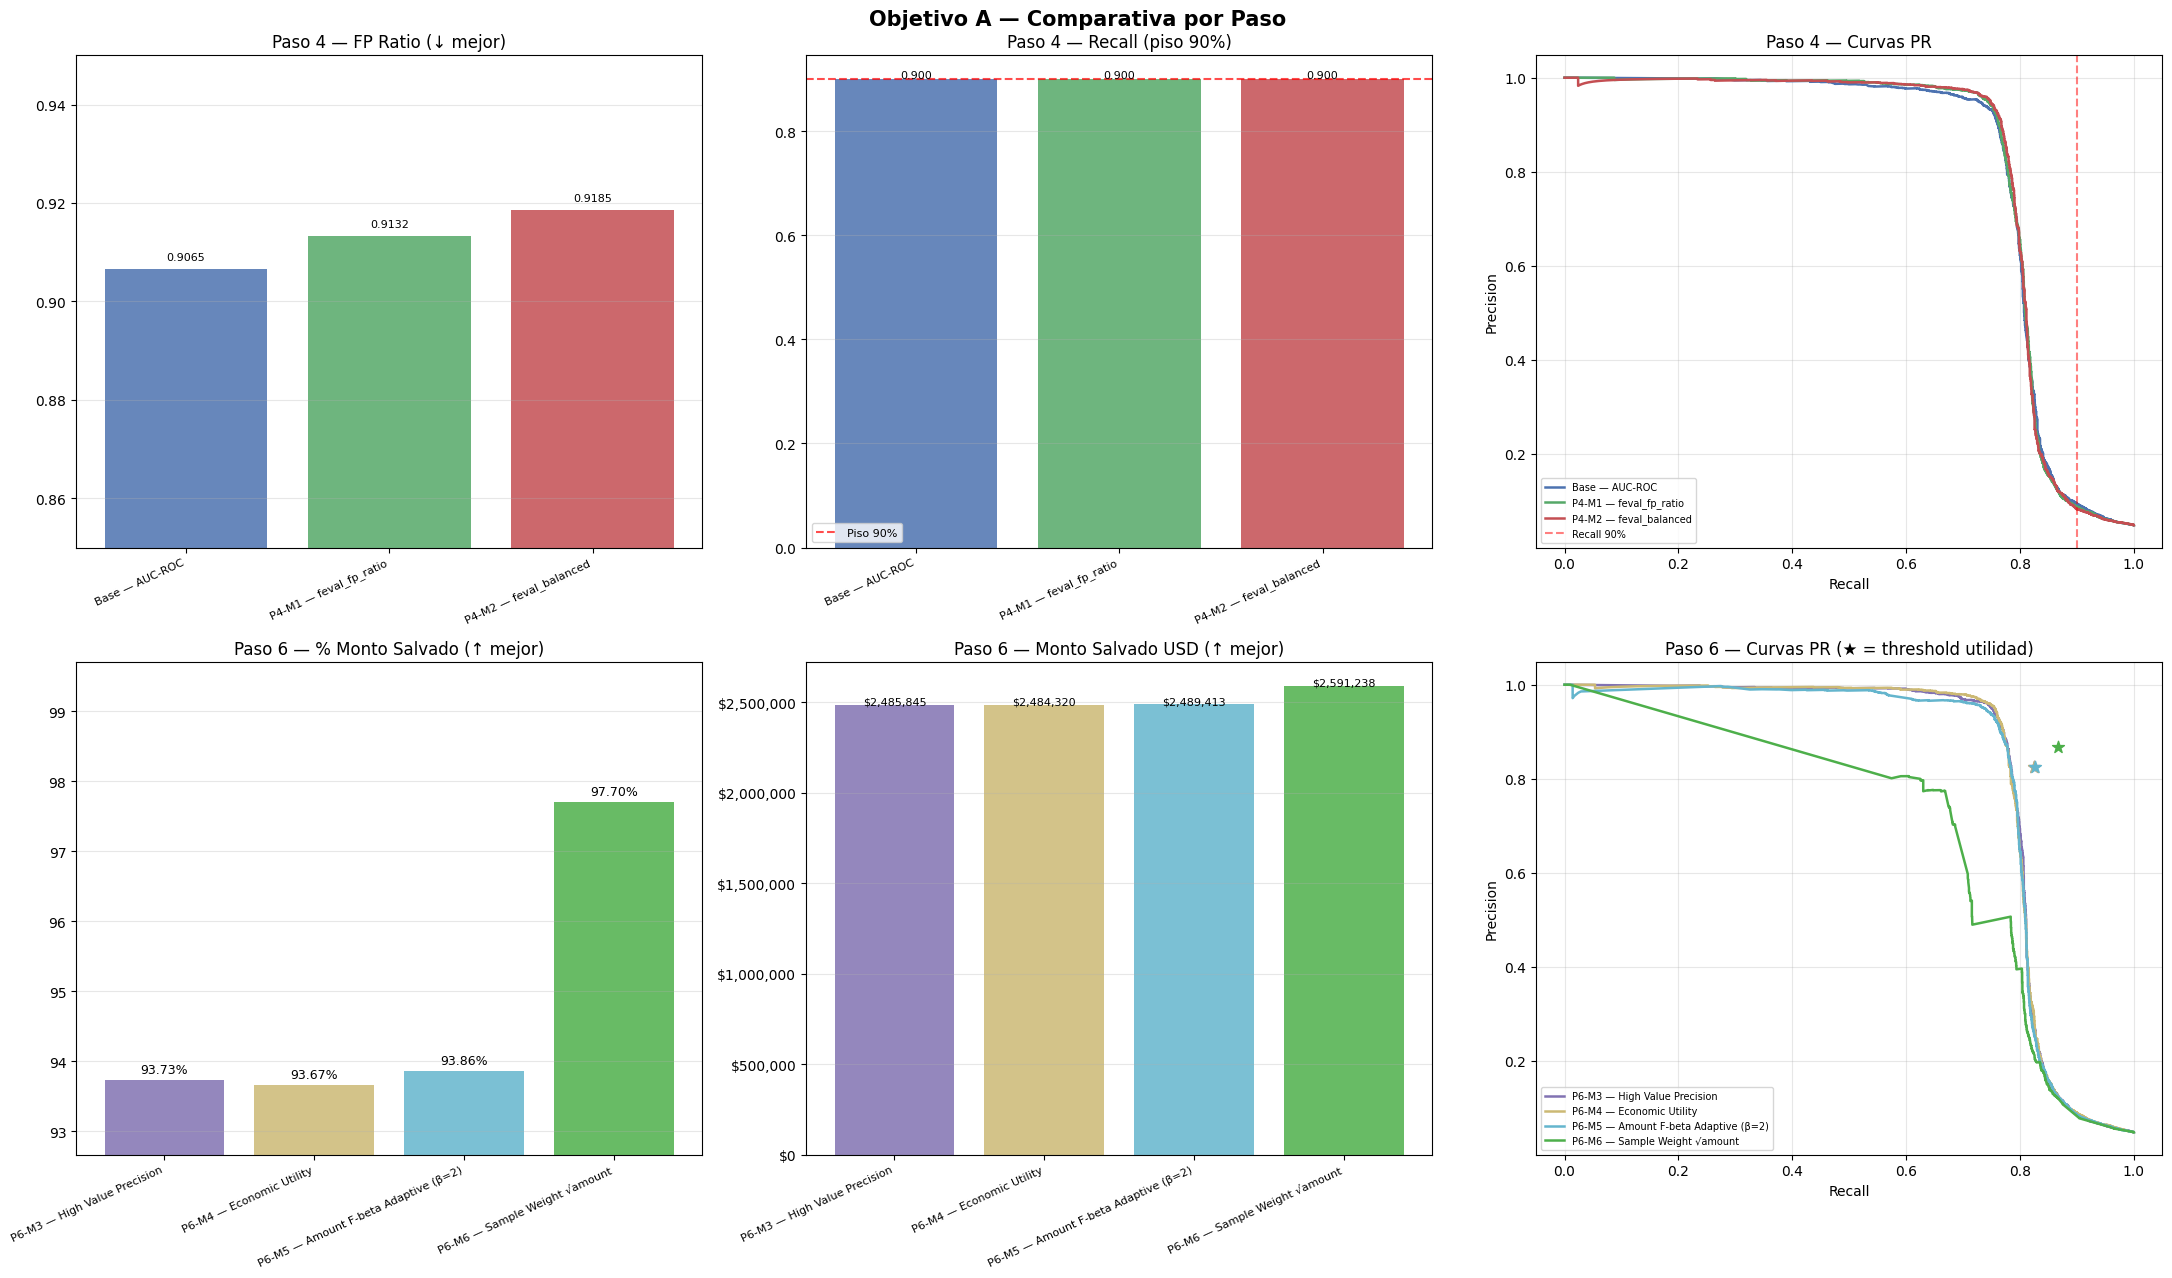

Guardado: /content/drive/MyDrive/proyecto_plus_ti/models/modelo_a/comparativa_v2.png


In [29]:
colores_p4 = ['#4C72B0', '#55A868', '#C44E52']
colores_p6 = ['#8172B2', '#CCB974', '#64B5CD', '#4DAF4A']

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Objetivo A — Comparativa por Paso', fontsize=15, fontweight='bold')

# ── Fila 0: Paso 4 ─────────────────────────────────────────────────────────────
modelos_p4 = df_p4.index.tolist()
x4 = np.arange(len(modelos_p4))

# FP Ratio P4
ax = axes[0, 0]
bars = ax.bar(x4, df_p4['FP Ratio'].values, color=colores_p4, alpha=0.85)
ax.set_xticks(x4); ax.set_xticklabels(modelos_p4, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 4 — FP Ratio (↓ mejor)')
for b, v in zip(bars, df_p4['FP Ratio'].values):
    ax.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.4f}', ha='center', fontsize=8)
ax.set_ylim(0.85, 0.95); ax.grid(axis='y', alpha=0.3)

# Recall P4
ax = axes[0, 1]
bars = ax.bar(x4, df_p4['Recall'].values, color=colores_p4, alpha=0.85)
ax.axhline(0.90, color='red', linestyle='--', alpha=0.7, label='Piso 90%')
ax.set_xticks(x4); ax.set_xticklabels(modelos_p4, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 4 — Recall (piso 90%)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, df_p4['Recall'].values):
    ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.3f}', ha='center', fontsize=8)

# Curvas PR P4
ax = axes[0, 2]
for prob, label, color in zip(
    [prob_base, prob_fp, prob_bal], modelos_p4, colores_p4
):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, label=label, color=color, linewidth=1.8)
ax.axvline(0.90, color='red', linestyle='--', alpha=0.5, label='Recall 90%')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Paso 4 — Curvas PR'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Fila 1: Paso 6 ─────────────────────────────────────────────────────────────
modelos_p6 = df_p6.index.tolist()
x6 = np.arange(len(modelos_p6))

# % Monto Salvado P6
ax = axes[1, 0]
bars = ax.bar(x6, df_p6['% Monto Salvado'].values, color=colores_p6, alpha=0.85)
ax.set_xticks(x6); ax.set_xticklabels(modelos_p6, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 6 — % Monto Salvado (↑ mejor)')
for b, v in zip(bars, df_p6['% Monto Salvado'].values):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.2f}%', ha='center', fontsize=9)
ax.set_ylim(
    df_p6['% Monto Salvado'].min() - 1,
    min(df_p6['% Monto Salvado'].max() + 2, 100)
)
ax.grid(axis='y', alpha=0.3)

# Monto Salvado USD absoluto P6
ax = axes[1, 1]
salvado_vals = df_p6['Monto Salvado USD'].values
bars = ax.bar(x6, salvado_vals, color=colores_p6, alpha=0.85)
ax.set_xticks(x6); ax.set_xticklabels(modelos_p6, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 6 — Monto Salvado USD (↑ mejor)')
for b, v in zip(bars, salvado_vals):
    ax.text(b.get_x()+b.get_width()/2, v+1000, f'${v:,.0f}', ha='center', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

# Curvas PR P6
ax = axes[1, 2]
for prob, label, color in zip(
    [prob_hv, prob_eu, prob_afb, prob_sw], modelos_p6, colores_p6
):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, label=label, color=color, linewidth=1.8)
# Marcar el threshold de utilidad de cada modelo
for prob, thr, color in zip(
    [prob_hv, prob_eu, prob_afb, prob_sw],
    [thr_hv, thr_eu, thr_afb, thr_sw],
    colores_p6
):
    y_pred_t = (prob >= thr).astype(int)
    p_val = y_pred_t[y_test.values == 1].mean() if y_pred_t.sum() > 0 else 0
    r_val = (y_pred_t * (y_test.values == 1)).sum() / (y_test.values == 1).sum()
    ax.scatter([r_val], [p_val], color=color, s=80, zorder=5, marker='*')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Paso 6 — Curvas PR (★ = threshold utilidad)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_OUTPUTS}/comparativa_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {PATH_OUTPUTS}/comparativa_v2.png')

### Matrices de confusión — todos los modelos

Paso 4 usa threshold de recall ≥ 90%.
Paso 6 usa threshold de utilidad máxima.
Los valores absolutos reflejan el tamaño real del test set.

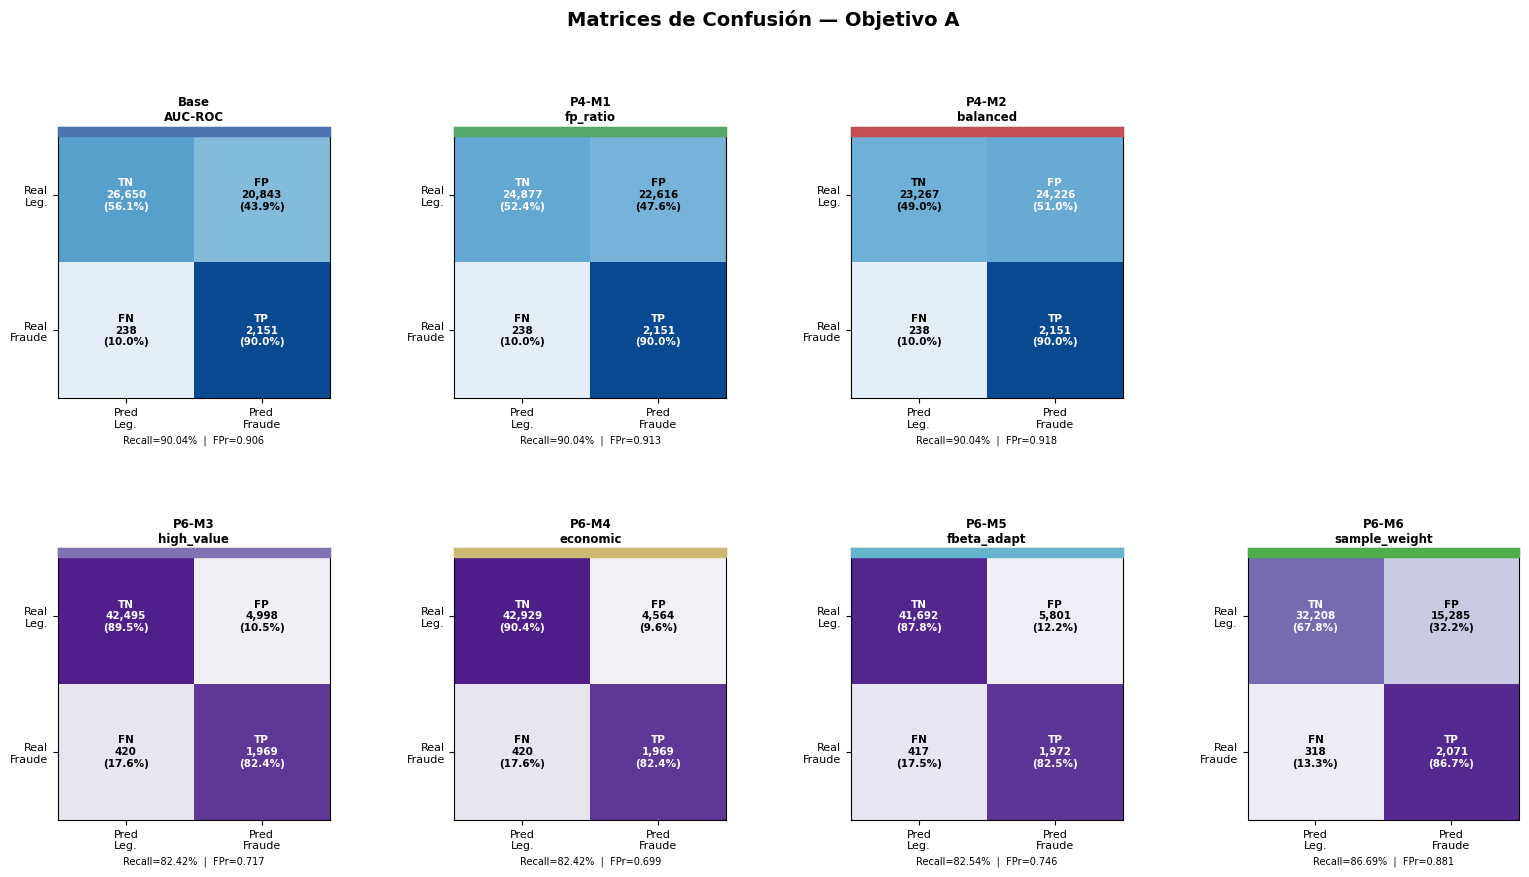

Guardado: /content/drive/MyDrive/proyecto_plus_ti/models/modelo_a/confusion_matrices.png


In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Datos de todos los modelos ────────────────────────────────────────────────
modelos_info = [
    # (nombre_corto, y_pred, paso, color_header)
    ('Base\nAUC-ROC',             pred_base, 'Paso 4', '#4C72B0'),
    ('P4-M1\nfp_ratio',           pred_fp,   'Paso 4', '#55A868'),
    ('P4-M2\nbalanced',           pred_bal,  'Paso 4', '#C44E52'),
    ('P6-M3\nhigh_value',         pred_hv,   'Paso 6', '#8172B2'),
    ('P6-M4\neconomic',           pred_eu,   'Paso 6', '#CCB974'),
    ('P6-M5\nfbeta_adapt',        pred_afb,  'Paso 6', '#64B5CD'),
    ('P6-M6\nsample_weight',      pred_sw,   'Paso 6', '#4DAF4A'),
]

y_true = y_test.values

fig = plt.figure(figsize=(20, 9))
fig.suptitle('Matrices de Confusión — Objetivo A', fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.10)

for idx, (nombre, y_pred, paso, color) in enumerate(modelos_info):
    row = 0 if paso == 'Paso 4' else 1
    col = idx if paso == 'Paso 4' else idx - 3

    ax = fig.add_subplot(gs[row, col])

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Normalizar por fila para el color (pero mostrar absolutos)
    cm_norm = cm.astype(float)
    cm_norm[0] /= cm_norm[0].sum()
    cm_norm[1] /= cm_norm[1].sum()

    # Colormap distinto por paso
    cmap = 'Blues' if paso == 'Paso 4' else 'Purples'
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)

    # Etiquetas con valor absoluto + porcentaje de fila
    labels = [
        [f'TN\n{tn:,}\n({tn/(tn+fp):.1%})', f'FP\n{fp:,}\n({fp/(tn+fp):.1%})'],
        [f'FN\n{fn:,}\n({fn/(fn+tp):.1%})', f'TP\n{tp:,}\n({tp/(fn+tp):.1%})'],
    ]
    for i in range(2):
        for j in range(2):
            val = cm_norm[i, j]
            text_color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, labels[i][j], ha='center', va='center',
                    fontsize=7.5, color=text_color, fontweight='bold')

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred\nLeg.', 'Pred\nFraude'], fontsize=8)
    ax.set_yticklabels(['Real\nLeg.', 'Real\nFraude'], fontsize=8)

    # Header con color por paso
    ax.set_title(nombre, fontsize=8.5, fontweight='bold', pad=4)
    ax.add_patch(plt.Rectangle((-0.5, -0.5), 2, 0.07,
                  transform=ax.transData, color=color, clip_on=False, zorder=10))

    # Métricas clave debajo
    recall_val   = tp / (tp + fn) if (tp + fn) > 0 else 0
    fp_ratio_val = fp / (tp + fp) if (tp + fp) > 0 else 1
    ax.set_xlabel(
        f'Recall={recall_val:.2%}  |  FPr={fp_ratio_val:.3f}',
        fontsize=7, labelpad=4
    )


plt.savefig(f'{PATH_OUTPUTS}/confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: {PATH_OUTPUTS}/confusion_matrices.png')

### Feature importance — modelos P6

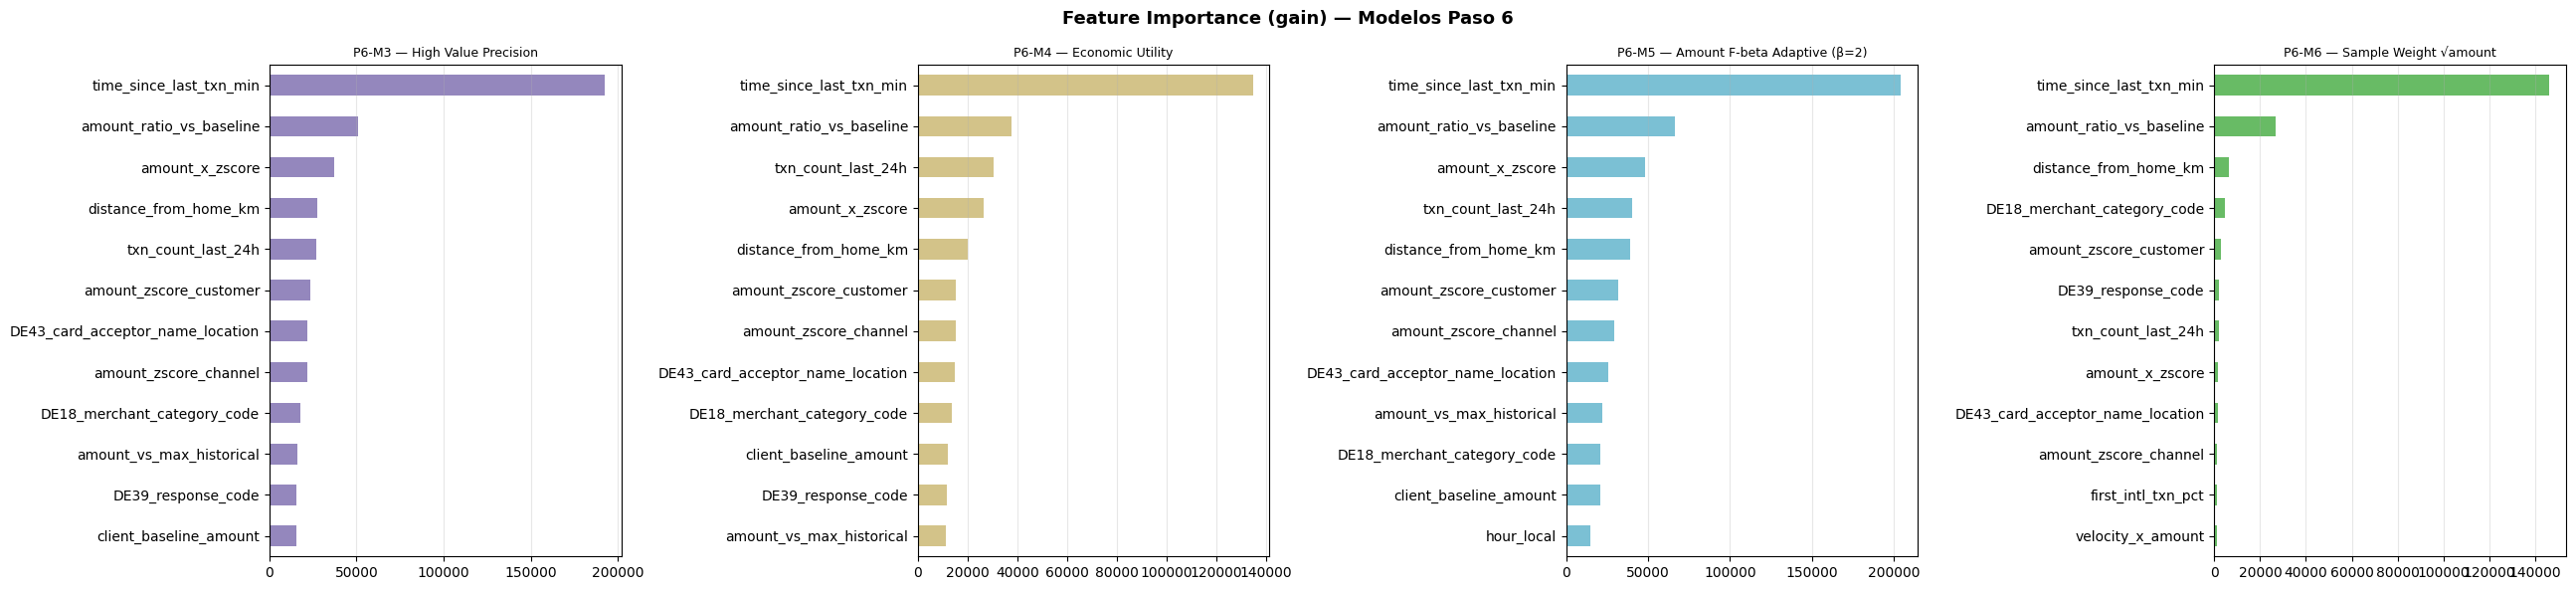

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(26, 6))
fig.suptitle('Feature Importance (gain) — Modelos Paso 6', fontsize=13, fontweight='bold')

for ax, model, name, color in zip(
    axes,
    [model_hv, model_eu, model_afb, model_sw],
    modelos_p6,
    colores_p6
):
    fi = pd.Series(
        model.feature_importance(importance_type='gain'),
        index=FEATURES
    ).sort_values(ascending=True).tail(12)
    fi.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(name, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_OUTPUTS}/feature_importance_p6.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 9. Conclusión y selección de función feval

## Paso 4 (punto común)
**Criterio:** menor FP ratio con recall ≥ 90%.

In [31]:
# ── Paso 4: selección ─────────────────────────────────────────────────────────
cand_p4 = df_p4[df_p4['Recall'] >= 0.90].copy()

if len(cand_p4):
    mejor_p4 = cand_p4['FP Ratio'].idxmin()
    print('Paso 4 — modelos con recall ≥ 90%:')
    print(cand_p4[['Recall','FP Ratio','FP','% Monto Salvado']].to_string())
    print(f'\n→ Seleccionado: {mejor_p4}')
    print(f'  FP Ratio : {cand_p4.loc[mejor_p4, "FP Ratio"]:.4f}')
    print(f'  Recall   : {cand_p4.loc[mejor_p4, "Recall"]:.2%}')
    print(f'  FP       : {int(cand_p4.loc[mejor_p4, "FP"]):,}')
else:
    print('⚠ Ningún modelo alcanzó recall ≥ 90%. Revisar parámetros.')

Paso 4 — modelos con recall ≥ 90%:
                        Recall  FP Ratio     FP  % Monto Salvado
Modelo                                                          
Base — AUC-ROC          0.9004    0.9065  20843            96.65
P4-M1 — feval_fp_ratio  0.9004    0.9132  22616            96.51
P4-M2 — feval_balanced  0.9004    0.9185  24226            96.79

→ Seleccionado: Base — AUC-ROC
  FP Ratio : 0.9065
  Recall   : 90.04%
  FP       : 20,843


## Paso 6 (objetivo del grupo)
**Criterio:** mayor monto salvado en USD con threshold de utilidad máxima.

In [48]:
# ── Paso 6: selección ─────────────────────────────────────────────────────────
mejor_p6 = df_p6['Monto Salvado USD'].idxmax()

print('Paso 6 — comparativa completa:')
cols_show = ['Threshold','Recall','Precision','FP Ratio','FP','Monto Salvado USD','% Monto Salvado']
print(df_p6[cols_show].to_string())

# Identificar el modelo más eficiente (monto / FP)
df_p6['usd_per_fp'] = df_p6['Monto Salvado USD'] / (df_p6['FP'] + 1)
mas_eficiente = df_p6['usd_per_fp'].idxmax()

print(f"""
CONCLUSIÓN PASO 6
=================
Objetivo: maximizar monto de fraude detectado en USD.
Threshold: maximiza utilidad = Σ(amount_usd de TP) − 5 × FP  (sin restricción de recall).

Cuatro estrategias evaluadas — dos trade-offs distintos:

  Alta precisión / bajo FP:
    {df_p6.index[df_p6['FP'] == df_p6['FP'].min()][0]}
      FP={int(df_p6['FP'].min()):,}  |  % Monto={df_p6.loc[df_p6['FP'].idxmin(),'% Monto Salvado']:.2f}%

  Alto monto / mayor FP:
    {mejor_p6}
      FP={int(df_p6.loc[mejor_p6,'FP']):,}  |  % Monto={df_p6.loc[mejor_p6,'% Monto Salvado']:.2f}%
      Diferencia USD vs modelo más selectivo: +${df_p6.loc[mejor_p6,'Monto Salvado USD'] - df_p6.loc[df_p6['FP'].idxmin(),'Monto Salvado USD']:,.2f}

Modelo seleccionado: {mejor_p6}
─────────────────────────────────────────────────────
  Monto Salvado USD : ${df_p6.loc[mejor_p6,'Monto Salvado USD']:,.2f}
  % Monto Salvado   : {df_p6.loc[mejor_p6,'% Monto Salvado']:.2f}%
  Recall            : {df_p6.loc[mejor_p6,'Recall']:.2%}
  Precision         : {df_p6.loc[mejor_p6,'Precision']:.4f}
  FP Ratio          : {df_p6.loc[mejor_p6,'FP Ratio']:.4f}
  FP absolutos      : {int(df_p6.loc[mejor_p6,'FP']):,}
  Threshold         : {df_p6.loc[mejor_p6,'Threshold']}

Justificación:
  sample_weight ∝ √amount_usd alineó la función de pérdida del árbol con el
  objetivo de negocio: equivocarse en un fraude de USD 2,000 penaliza ~4.5×
  más que en uno de USD 100. Esto eleva el % monto salvado a {df_p6.loc[mejor_p6,'% Monto Salvado']:.2f}% —
  el mayor de los cuatro modelos — al costo de un FP ratio similar al Paso 4.

  Si la capacidad operativa del banco es limitada (pocas alertas investigables),
  {df_p6.index[df_p6['FP'] == df_p6['FP'].min()][0]} es preferible:
  FP={int(df_p6['FP'].min()):,} con % monto={df_p6.loc[df_p6['FP'].idxmin(),'% Monto Salvado']:.2f}%.
  La elección entre ambos depende del costo operativo real por alerta.

Comparativa de thresholds:
  Paso 4 (recall ≥ 90%) → FP ~{int(df_p4['FP'].min()):,} | FP ratio ~{df_p4['FP Ratio'].min():.2f}
  Paso 6 modelo selectivo → FP ~{int(df_p6['FP'].min()):,} | FP ratio ~{df_p6.loc[df_p6['FP'].idxmin(),'FP Ratio']:.2f}
  Paso 6 modelo agresivo  → FP ~{int(df_p6.loc[mejor_p6,'FP']):,} | FP ratio ~{df_p6.loc[mejor_p6,'FP Ratio']:.2f}

  La reducción de FP en los modelos selectivos del Paso 6 no viene de un modelo
  más complejo: viene de optimizar el threshold para el objetivo correcto.
""")

Paso 6 — comparativa completa:
                                      Threshold  Recall  Precision  FP Ratio     FP  Monto Salvado USD  % Monto Salvado
Modelo                                                                                                                 
P6-M3 — High Value Precision             0.1299  0.8242     0.2826    0.7174   4998         2485844.74            93.73
P6-M4 — Economic Utility                 0.1353  0.8242     0.3014    0.6986   4564         2484320.33            93.67
P6-M5 — Amount F-beta Adaptive (β=2)     0.1394  0.8254     0.2537    0.7463   5801         2489412.88            93.86
P6-M6 — Sample Weight √amount            0.1033  0.8669     0.1193    0.8807  15285         2591238.01            97.70

CONCLUSIÓN PASO 6
Objetivo: maximizar monto de fraude detectado en USD.
Threshold: maximiza utilidad = Σ(amount_usd de TP) − 5 × FP  (sin restricción de recall).

Cuatro estrategias evaluadas — dos trade-offs distintos:

  Alta precisión / bajo FP: